# Data Science Workflow: Optimized AAPL Stock Prediction
This notebook demonstrates an advanced optimization workflow: Using `StandardScaler`, enriched technical features (Bollinger Bands, VROC), and a hyperparameter tuning loop to identify the best lookback window.

## 1. Setup & Imports

In [15]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

## 2. Acquire Data

In [16]:
tickers = ['AAPL', '^TNX', '^VIX']
data = yf.download(tickers, start='2015-01-01', end='2024-01-01')

df = pd.DataFrame()
# Reconstruct AAPL columns
df['Open'] = data['Open']['AAPL']
df['High'] = data['High']['AAPL']
df['Low'] = data['Low']['AAPL']
df['Close'] = data['Close']['AAPL']
df['Volume'] = data['Volume']['AAPL']

# Extract TNX and VIX columns
df['TNX_Close'] = data['Close']['^TNX']
df['VIX_Close'] = data['Close']['^VIX']

df.dropna(inplace=True)
df.head()

[*********************100%***********************]  3 of 3 completed


,Open,High,Low,Close,Volume,TNX_Close,VIX_Close
Date,,,,,,,
2015-01-02,24.671157,24.682231,23.776359,24.214899,212818400,2.123,17.790001
2015-01-05,23.984551,24.064285,23.346676,23.532722,257142000,2.039,19.920000
2015-01-06,23.596952,23.794073,23.173916,23.534937,263188400,1.963,21.120001
2015-01-07,23.743124,23.964608,23.632381,23.864941,160423600,1.954,19.309999
2015-01-08,24.192747,24.839481,24.075359,24.781895,237458000,2.016,17.010000


## 3. Advanced Feature Engineering
We are adding:
- **Bollinger Bands**: To capture volatility.
- **VROC (Volume Rate of Change)**: To capture volume momentum.
- **Price/SMA Ratios**: To normalize the trend position.
- **Percentage Returns**: As the stationary target.

In [17]:
# 1. Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# 2. Bollinger Bands
std_20 = df['Close'].rolling(window=20).std()
df['Upper_BB'] = df['SMA_20'] + (std_20 * 2)
df['Lower_BB'] = df['SMA_20'] - (std_20 * 2)

# 3. Volume Rate of Change (VROC)
df['VROC'] = df['Volume'].pct_change(periods=10)

# 4. MACD & RSI
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# 5. Price-to-SMA Ratio
df['Price_SMA_Ratio'] = df['Close'] / df['SMA_20']

# 6. Target Variable & Macro Indicators
df['Return'] = df['Close'].pct_change()
df['TNX_Return'] = df['TNX_Close'].pct_change()
df['VIX_Return'] = df['VIX_Close'].pct_change()

df.dropna(inplace=True)
df.tail()

,Open,High,Low,Close,Volume,TNX_Close,VIX_Close,SMA_20,SMA_50,Upper_BB,Lower_BB,VROC,MACD,Signal_Line,RSI,Price_SMA_Ratio,Return,TNX_Return,VIX_Return
Date,,,,,,,,,,,,,,,,,,,
2023-12-22,193.173224,193.400870,190.985954,191.609482,37149600,3.901,13.03,191.677261,183.401250,197.439432,185.915089,-0.304398,2.630681,3.232231,59.246158,0.999646,-0.005547,0.001798,-0.045421
2023-12-26,191.619349,191.896469,190.847370,191.065109,28919300,3.886,12.99,191.838584,183.686988,197.322180,186.354989,-0.525475,2.302596,3.046304,49.031880,0.995968,-0.002841,-0.003845,-0.003070
2023-12-27,190.510890,191.510500,189.125276,191.164093,48087700,3.789,12.43,191.974671,183.977275,197.233885,186.715458,-0.087466,2.027206,2.842484,52.291568,0.995778,0.000518,-0.024961,-0.043110
2023-12-28,192.143931,192.658589,191.183903,191.589691,34049900,3.850,12.47,192.183009,184.307110,196.994042,187.371975,-0.516366,1.822293,2.638446,47.920525,0.996913,0.002226,0.016099,0.003218
2023-12-29,191.906370,192.401229,189.758683,190.550461,42672100,3.866,12.45,192.310683,184.642058,196.777167,187.844198,-0.361498,1.558080,2.422373,40.185254,0.990847,-0.005424,0.004156,-0.001604


## 4. Hyperparameter Tuning & Preprocessing
We will define a utility function to preprocess data for different `lookback` windows and a simple tuning loop.

In [18]:
def prepare_data(df, lookback, features, target_col):
    # Use StandardScaler for better handling of Return distributions
    scaler_f = StandardScaler()
    scaled_f = scaler_f.fit_transform(df[features].values)
    
    scaler_t = StandardScaler()
    scaled_t = scaler_t.fit_transform(df[[target_col]].values)
    
    X, y = [], []
    for i in range(lookback, len(scaled_f)):
        X.append(scaled_f[i-lookback:i, :])
        y.append(scaled_t[i, 0])
        
    X, y = np.array(X), np.array(y)
    split = int(len(X) * 0.8)
    return X[:split], X[split:], y[:split], y[split:], scaler_f, scaler_t

def build_model(input_shape, model_type='LSTM'):
    model = Sequential()
    if model_type == 'LSTM':
        model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape))
        model.add(Dropout(0.2))
        model.add(LSTM(32))
    else:
        model.add(Bidirectional(GRU(64, return_sequences=True), input_shape=input_shape))
        model.add(Dropout(0.2))
        model.add(GRU(32))
    
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='huber') 
    return model

features_list = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'SMA_50', 'Upper_BB', 'Lower_BB', 'VROC', 'MACD', 'Signal_Line', 'RSI', 'Price_SMA_Ratio', 'TNX_Close', 'TNX_Return', 'VIX_Close', 'VIX_Return', 'Return']

### Simple Hyperparameter Tuning: Exploring Lookback Windows
We will test lookback windows of 30 vs 60 days to find the best balance.

In [19]:
results = {}
lookbacks_to_test = [30, 60]

for lb in lookbacks_to_test:
    print(f"\n--- Testing Lookback: {lb} days ---")
    X_train, X_test, y_train, y_test, _, scaler_t = prepare_data(df, lb, features_list, 'Return')
    
    model = build_model((X_train.shape[1], X_train.shape[2]), 'LSTM')
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0, callbacks=[early_stop])
    
    # Calculate simple validation loss
    val_loss = min(history.history['val_loss'])
    results[lb] = val_loss
    print(f"Best Validation Loss for {lb} days: {val_loss:.4f}")

best_lookback = min(results, key=results.get)
print(f"\nBest Lookback Window Identified: {best_lookback} days")



--- Testing Lookback: 30 days ---
Best Validation Loss for 30 days: 0.3344

--- Testing Lookback: 60 days ---
Best Validation Loss for 60 days: 0.3483

Best Lookback Window Identified: 30 days


## 5. Final Model Training (Optimized)
We train our final LSTM and GRU versions using the `best_lookback` discovered above.

In [20]:
# Prepare Final Data
X_train, X_test, y_train, y_test, scaler_f, scaler_t = prepare_data(df, best_lookback, features_list, 'Return')

# Store prices for reconstruction
actual_prices_test = df['Close'].values[best_lookback + int(len(df[best_lookback:])*0.8):]
prev_prices_test = df['Close'].values[best_lookback + int(len(df[best_lookback:])*0.8) - 1 : -1]

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

print("Training Final Optimized LSTM...")
model_lstm = build_model((X_train.shape[1], X_train.shape[2]), 'LSTM')
history_lstm = model_lstm.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1, callbacks=callbacks)

print("\nTraining Final Optimized GRU...")
model_gru = build_model((X_train.shape[1], X_train.shape[2]), 'GRU')
history_gru = model_gru.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1, callbacks=callbacks)


Training Final Optimized LSTM...
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.4018 - val_loss: 0.3326 - learning_rate: 5.0000e-04
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3578 - val_loss: 0.3306 - learning_rate: 5.0000e-04
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3767 - val_loss: 0.3480 - learning_rate: 5.0000e-04
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3767 - val_loss: 0.3362 - learning_rate: 5.0000e-04
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3479 - val_loss: 0.3352 - learning_rate: 5.0000e-04
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3678 - val_loss: 0.3440 - learning_rate: 5.0000e-04
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3623 - val_loss: 0.3632 - learning_rate: 5.0000e-04
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3602 - val_loss: 0.3431 - learning_rate: 5.0000e-04
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - l

## 6. Evaluation & Visualization
Reconstructing absolute prices and checking directional metrics on the test set.

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


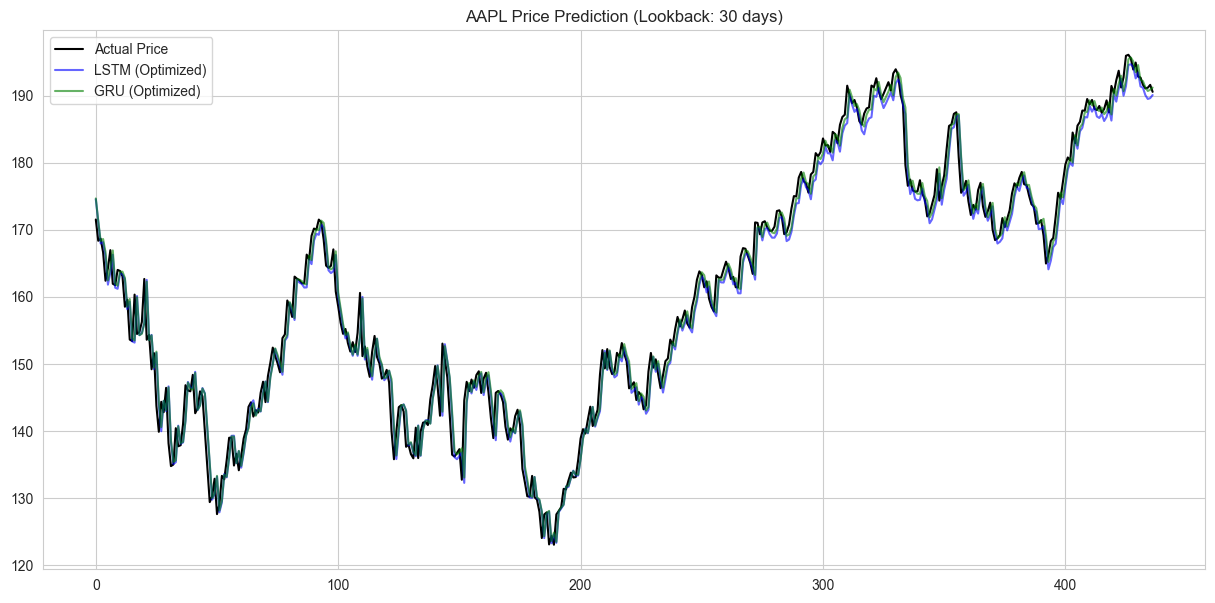

[LSTM] RMSE: 2.87 | Acc: 51.72% | F1: 0.3259
[GRU] RMSE: 2.75 | Acc: 53.32% | F1: 0.4874


In [21]:
# Predictions (Returns)
pred_lstm_ret = scaler_t.inverse_transform(model_lstm.predict(X_test)).flatten()
pred_gru_ret = scaler_t.inverse_transform(model_gru.predict(X_test)).flatten()
y_test_ret = scaler_t.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Price Reconstruction
pred_lstm_price = prev_prices_test * (1 + pred_lstm_ret)
pred_gru_price = prev_prices_test * (1 + pred_gru_ret)

# Visuals
plt.figure(figsize=(15, 7))
plt.plot(actual_prices_test, label='Actual Price', color='black', linewidth=1.5)
plt.plot(pred_lstm_price, label='LSTM (Optimized)', color='blue', alpha=0.6)
plt.plot(pred_gru_price, label='GRU (Optimized)', color='green', alpha=0.6)
plt.title(f'AAPL Price Prediction (Lookback: {best_lookback} days)')
plt.legend()
plt.show()

# Metrics
def get_metrics(model_name, actual_p, pred_p, actual_r, pred_r):
    rmse = np.sqrt(mean_squared_error(actual_p, pred_p))
    
    # Directional
    actual_dir = (actual_r > 0).astype(int)
    pred_dir = (pred_r > 0).astype(int)
    acc = accuracy_score(actual_dir, pred_dir)
    f1 = f1_score(actual_dir, pred_dir, zero_division=0)
    
    print(f"[{model_name}] RMSE: {rmse:.2f} | Acc: {acc*100:.2f}% | F1: {f1:.4f}")

get_metrics("LSTM", actual_prices_test, pred_lstm_price, y_test_ret, pred_lstm_ret)
get_metrics("GRU", actual_prices_test, pred_gru_price, y_test_ret, pred_gru_ret)
